Завдання 3
1. Обрати дані з Kaggle чи https://github.com/plotly/datasets
2. Побудувати модель глибокого навчання для задачі регресії чи задачі класифікації (в залежності який датасет буде обрано).
3. Провести компіляцію, навчання та тестування моделі.
4. Візуалізувати результати

All the imports in one place

In [1]:
import pandas as pd
import seaborn as sns
from scipy.signal.windows import triang
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')

Load the data for the regression

In [25]:
train_df = pd.read_csv('../data/mushrooms.csv')
train_df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [26]:
train_df.shape

(8124, 23)

In [27]:
train_df.describe(include='all')

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [28]:
train_df.isna().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Split data into training features and feature to predict

In [30]:
cols = ['cap-shape','cap-surface','cap-color','bruises','odor','gill-attachment','gill-spacing','gill-size','gill-color','stalk-shape','stalk-root','stalk-surface-above-ring','stalk-surface-below-ring','stalk-color-above-ring','stalk-color-below-ring','veil-type','veil-color','ring-number','ring-type','spore-print-color','population','habitat']
y_original = train_df['class']
X_original = train_df[cols]

In [31]:
y_original.head()

0    p
1    e
2    e
3    p
4    e
Name: class, dtype: str

In [32]:
X_original.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
y = train_df['class']
train_df = train_df.drop('class', axis=1)
X = train_df

In [7]:
X.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [8]:
y.head()

0    p
1    e
2    e
3    p
4    e
Name: class, dtype: str

Split the data into training, validation and test datasets

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
  X,y, random_state=42, test_size=0.3, shuffle=True, stratify=y)

In [10]:
X_test, X_val, y_test, y_val = train_test_split(
  X_test,y_test, random_state=42, test_size=0.33, shuffle=True, stratify=y_test)

One-hot encoding for categorical columns

In [11]:
encoder = OneHotEncoder(sparse_output=False)

encoder.fit(X_train)

X_train = encoder.transform(X_train)
X_test = encoder.transform(X_test)
X_val = encoder.transform(X_val)

# make it dataframe again
feature_names = encoder.get_feature_names_out(X.columns)
X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)
X_val = pd.DataFrame(X_val, columns=feature_names)

In [12]:
encoder_y = OneHotEncoder(sparse_output=False)

# Convert to DataFrame with a column name
y_train_df = y_train.to_frame(name='class')
encoder_y.fit(y_train_df)

# Transform the data
y_train_encoded = encoder_y.transform(y_train_df)
y_test_encoded = encoder_y.transform(y_test.to_frame(name='class'))
y_val_encoded = encoder_y.transform(y_val.to_frame(name='class'))

# Get feature names and create DataFrames
feature_names_y = encoder_y.get_feature_names_out(['class'])
y_train = pd.DataFrame(y_train_encoded, columns=feature_names_y)
y_test = pd.DataFrame(y_test_encoded, columns=feature_names_y)
y_val = pd.DataFrame(y_val_encoded, columns=feature_names_y)

Create model

In [13]:
def build_model(train, activator='relu', optimizer='adam', layers=3, neurons=128):
  model = Sequential()
  n_cols = train.shape[1]

  model.add(Input(shape=(n_cols,)))

  model.add(Dense(neurons, activation=activator))
  for i in range(layers - 1):
      model.add(Dense(neurons, activation=activator))
  model.add(Dense(2, activation='softmax'))

  model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [14]:
from sklearn.metrics import average_precision_score, f1_score


def get_metrics(test_y, y_pred):
    # Convert one-hot encoded true values to class labels
    y_true = np.argmax(test_y, axis=1)

    # Convert probability predictions to class labels
    y_pred_labels = np.argmax(y_pred, axis=1)

    # For binary classification, get probability of positive class (class 1)
    # This is needed for ROC-AUC and average precision
    y_pred_proba_positive = y_pred[:, 1]

    metrics = [
        accuracy_score(y_true, y_pred_labels),
        precision_score(y_true, y_pred_labels, average='binary'),  # for binary
        recall_score(y_true, y_pred_labels, average='binary'),  # for binary
        f1_score(y_true, y_pred_labels, average='binary'),  # for binary
    ]

    return metrics

In [15]:
layers = [2, 3, 4, 5, 6]
neurons = [6, 7, 9, 10, 16, 32, 64, 128, 256, 512]
models_diff_lay_neur = []

for l in layers :
    models = []
    for n in neurons :
        model = build_model(X_train, neurons=n, layers=l)
        models.append(model)
    models_diff_lay_neur.append(models)

metrics_diff_lay_neur = []

early_stopping_monitor = EarlyStopping(patience=3)

for layer_models in models_diff_lay_neur:
    layer_metrics = []
    for model in layer_models:
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            callbacks=[early_stopping_monitor],
            verbose=0
        )
        test_y_predictions = model.predict(X_test, verbose=0)
        new_metrics = get_metrics(y_test, test_y_predictions)
        layer_metrics.append(new_metrics)
    metrics_diff_lay_neur.append(layer_metrics)


# Створюємо DataFrame
df = pd.DataFrame(metrics_diff_lay_neur,
                  index=[f'{l} layers' for l in layers],
                  columns=[f'{n} neurons.' for n in neurons])

df = df.round(3)
print(df)

                                                 6 neurons.  \
2 layers                               [1.0, 1.0, 1.0, 1.0]   
3 layers  [0.9975505205143906, 1.0, 0.9949174078780177, ...   
4 layers  [0.9987752602571953, 1.0, 0.9974587039390089, ...   
5 layers  [0.9993876301285977, 1.0, 0.9987293519695044, ...   
6 layers  [0.9993876301285977, 1.0, 0.9987293519695044, ...   

                                                 7 neurons.  \
2 layers  [0.998162890385793, 1.0, 0.9961880559085133, 0...   
3 layers  [0.998162890385793, 1.0, 0.9961880559085133, 0...   
4 layers  [0.9993876301285977, 1.0, 0.9987293519695044, ...   
5 layers                               [1.0, 1.0, 1.0, 1.0]   
6 layers                               [1.0, 1.0, 1.0, 1.0]   

                                                 9 neurons.  \
2 layers  [0.998162890385793, 1.0, 0.9961880559085133, 0...   
3 layers  [0.9993876301285977, 1.0, 0.9987293519695044, ...   
4 layers  [0.9987752602571953, 1.0, 0.997458703939008

№   Layers   Neurons    Accuracy Precision Recall   F1      
--------------------------------------------------
1   6        512        1.0      1.0      1.0      1.0     
2   6        256        1.0      1.0      1.0      1.0     
3   6        128        1.0      1.0      1.0      1.0     
4   6        64         1.0      1.0      1.0      1.0     
5   6        32         1.0      1.0      1.0      1.0     
6   6        10         1.0      1.0      1.0      1.0     
7   6        9          1.0      1.0      1.0      1.0     
8   6        7          1.0      1.0      1.0      1.0     
9   5        512        1.0      1.0      1.0      1.0     
10  5        256        1.0      1.0      1.0      1.0     


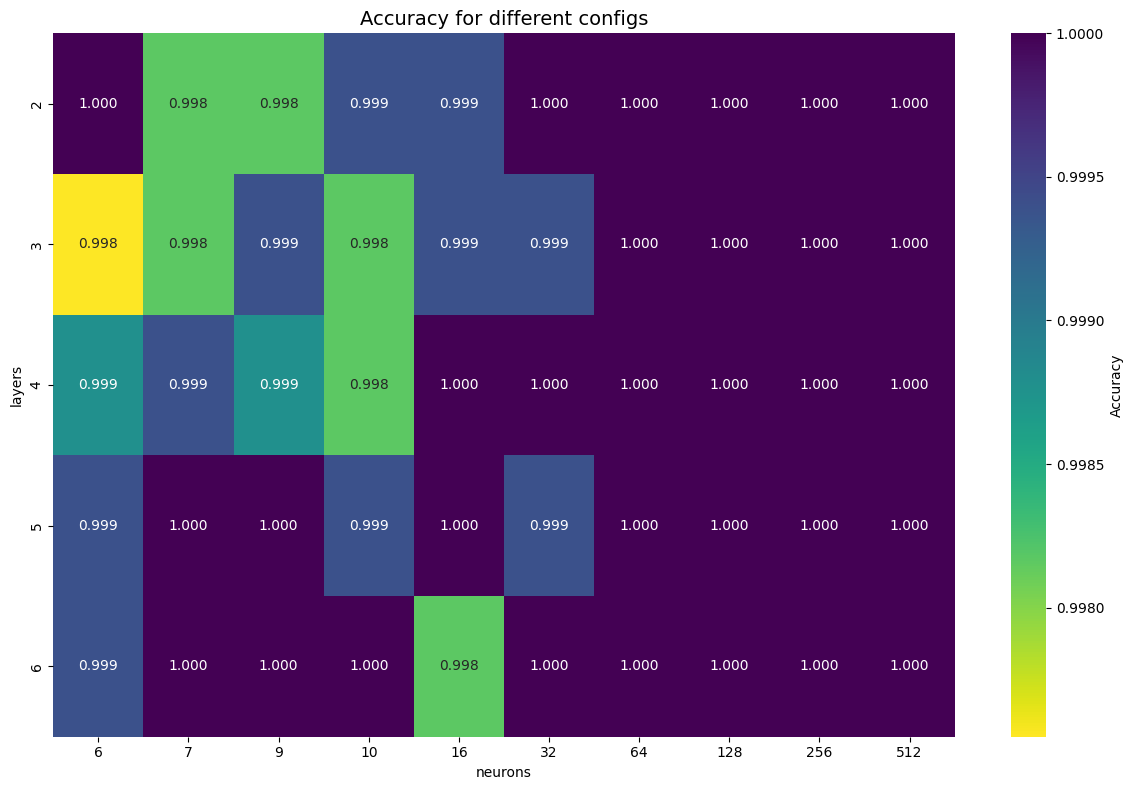

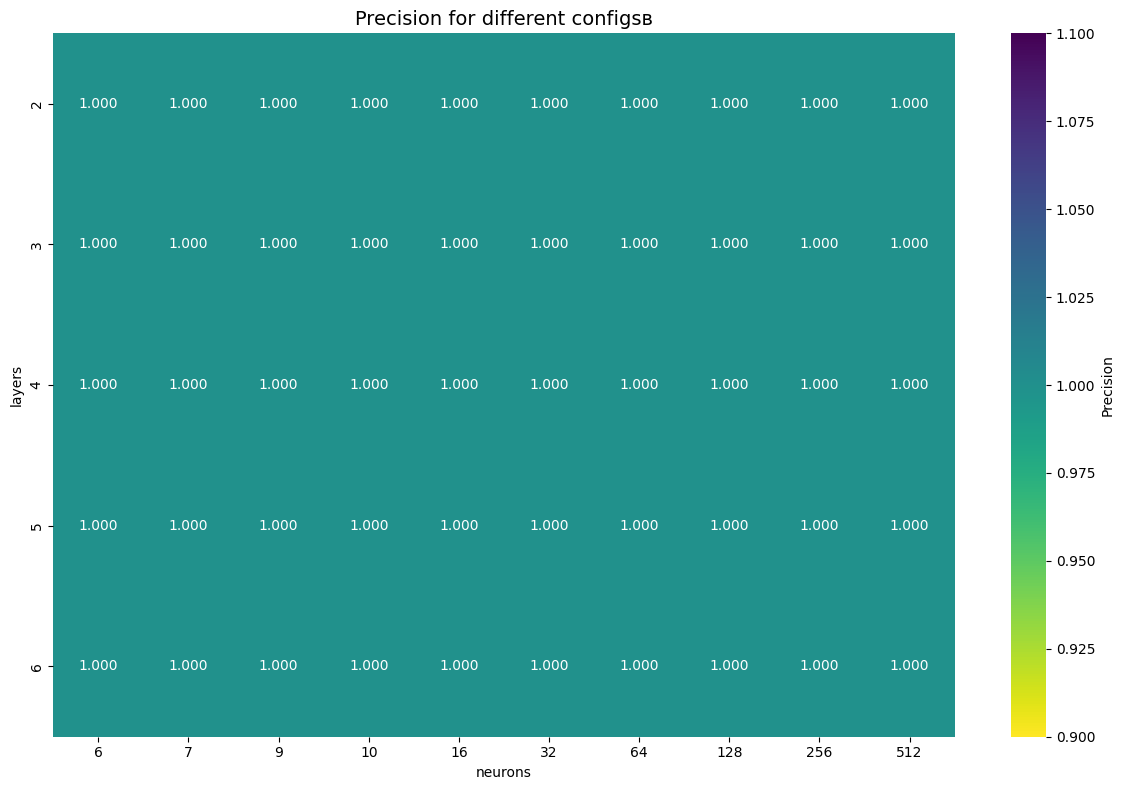

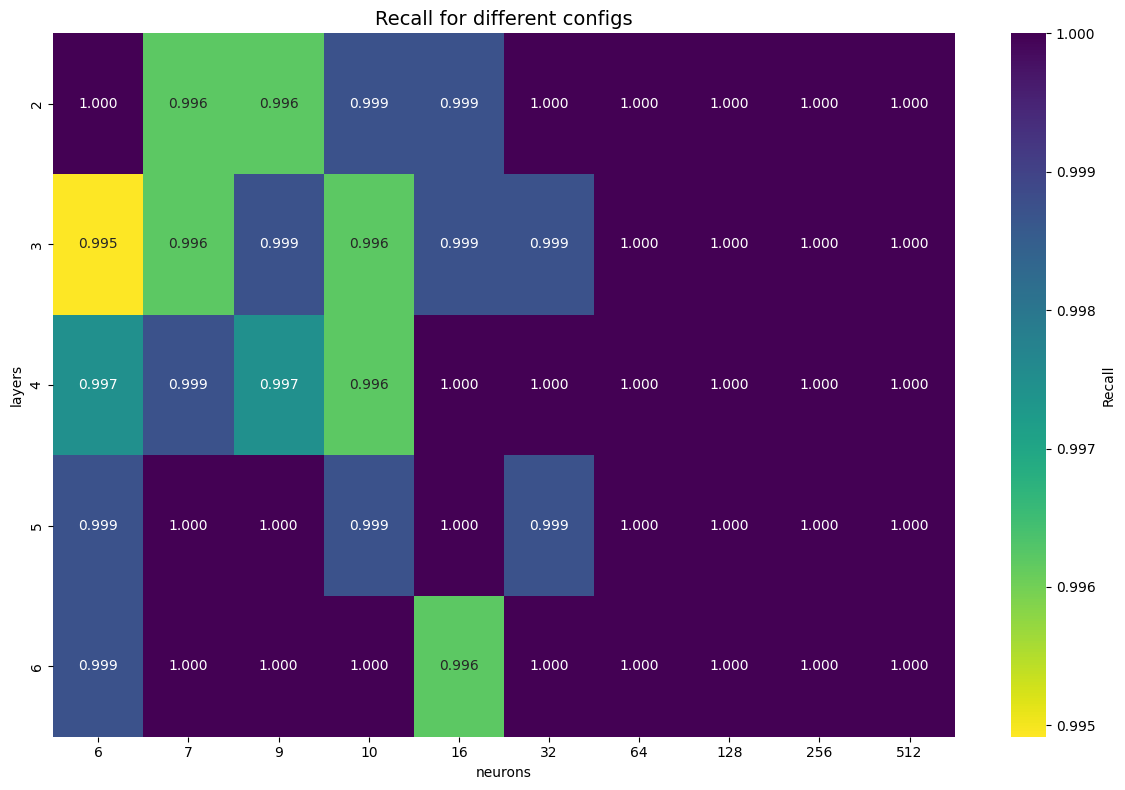

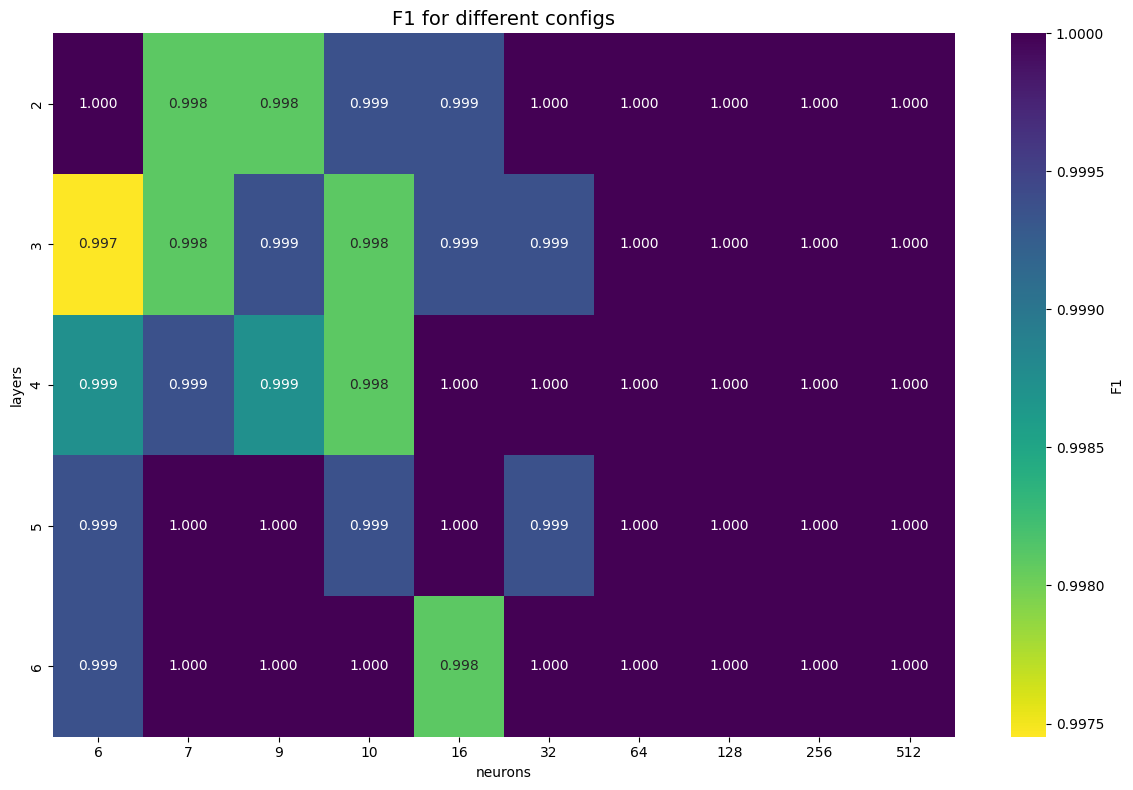

In [16]:
all_results = []
for i, l in enumerate(layers):
    for j, n in enumerate(neurons):
        accuracy, precision, recall, f1 = metrics_diff_lay_neur[i][j]
        all_results.append((accuracy, l, n, precision, recall, f1))

top_10 = sorted(all_results, reverse=True)[:10]

print(f"{'№':<3} {'Layers':<8} {'Neurons':<10} {'Accuracy':<8} {'Precision':<8} {'Recall':<8} {'F1':<8}")
print("-" * 50)

for i, (accuracy, l, n, precision, recall, f1) in enumerate(top_10, 1):
    print(f"{i:<3} {l:<8} {n:<10} {accuracy:<8} {precision:<8} {recall:<8} {f1:<8}")


# heatmap by Accuracy matrix
accuracy_matrix = np.array([[metrics_diff_lay_neur[i][j][0]
                         for j in range(len(neurons))]
                        for i in range(len(layers))])

plt.figure(figsize=(12, 8))
sns.heatmap(accuracy_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=neurons,
            yticklabels=layers,
            cmap='viridis_r',
            cbar_kws={'label': 'Accuracy'}
            )
plt.title('Accuracy for different configs', fontsize=14)
plt.xlabel('neurons')
plt.ylabel('layers')
plt.tight_layout()
plt.show()

# heatmap by Precision matrix
precision_matrix = np.array([[metrics_diff_lay_neur[i][j][1]
                         for j in range(len(neurons))]
                        for i in range(len(layers))])

plt.figure(figsize=(12, 8))
sns.heatmap(precision_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=neurons,
            yticklabels=layers,
            cmap='viridis_r',
            cbar_kws={'label': 'Precision'}
            )
plt.title('Precision for different configsв', fontsize=14)
plt.xlabel('neurons')
plt.ylabel('layers')
plt.tight_layout()
plt.show()

# heatmap by Recall matrix
recall_matrix = np.array([[metrics_diff_lay_neur[i][j][2]
                         for j in range(len(neurons))]
                        for i in range(len(layers))])

plt.figure(figsize=(12, 8))
sns.heatmap(recall_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=neurons,
            yticklabels=layers,
            cmap='viridis_r',
            cbar_kws={'label': 'Recall'}
            )
plt.title('Recall for different configs', fontsize=14)
plt.xlabel('neurons')
plt.ylabel('layers')
plt.tight_layout()
plt.show()

# heatmap by F1 matrix
f1_matrix = np.array([[metrics_diff_lay_neur[i][j][3]
                         for j in range(len(neurons))]
                        for i in range(len(layers))])

plt.figure(figsize=(12, 8))
sns.heatmap(f1_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=neurons,
            yticklabels=layers,
            cmap='viridis_r',
            cbar_kws={'label': 'F1'}
            )
plt.title('F1 for different configs', fontsize=14)
plt.xlabel('neurons')
plt.ylabel('layers')
plt.tight_layout()
plt.show()

Try different optimizers in models

In [18]:
optimizers = ['adam', 'rmsprop', 'sgd', 'adadelta', 'adagrad', 'adamax', 'nadam']
activators = ['relu', 'tanh', 'sigmoid', 'softmax', 'silu', 'elu', 'gelu']

models_opt_act = []
metrics_opt_act = []

histories = []
predictions = []

for opt in optimizers:
    models = []
    pred = []
    hists = []
    for act in activators:

        model = build_model(X_train, optimizer=opt, activator=act, layers=2, neurons=6)
        models.append(model)

        early_stopping_monitor = EarlyStopping(patience=3)
        history = model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=100,
            callbacks=[early_stopping_monitor],
            verbose=0
        )
        hists.append(history.history)

        test_y_predictions = model.predict(X_test)
        pred.append(test_y_predictions)

    models_opt_act = models
    histories.append(hists)
    predictions.append(pred)


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
52/52 ━━━━━━━━━━━━━━━━━

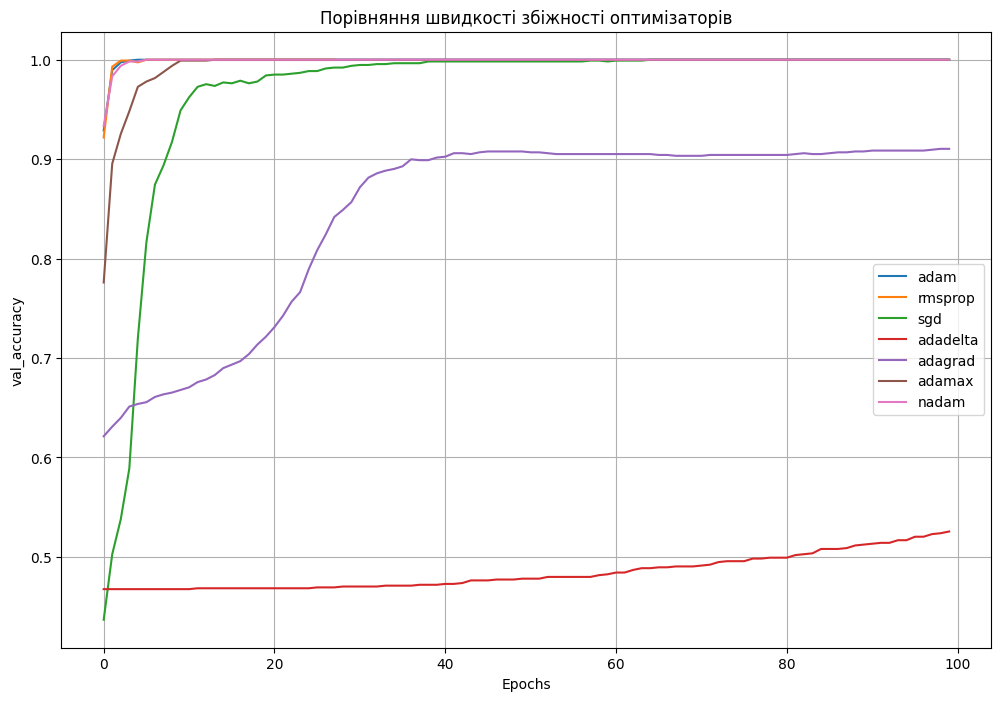

In [19]:
plt.figure(figsize=(12, 8))

for opt, history in zip(optimizers, histories):
    plt.plot(history[0]['val_accuracy'], label=opt)

plt.title('Порівняння швидкості збіжності оптимізаторів')
plt.xlabel('Epochs')
plt.ylabel('val_accuracy')
plt.legend()
plt.grid(True)
plt.show()

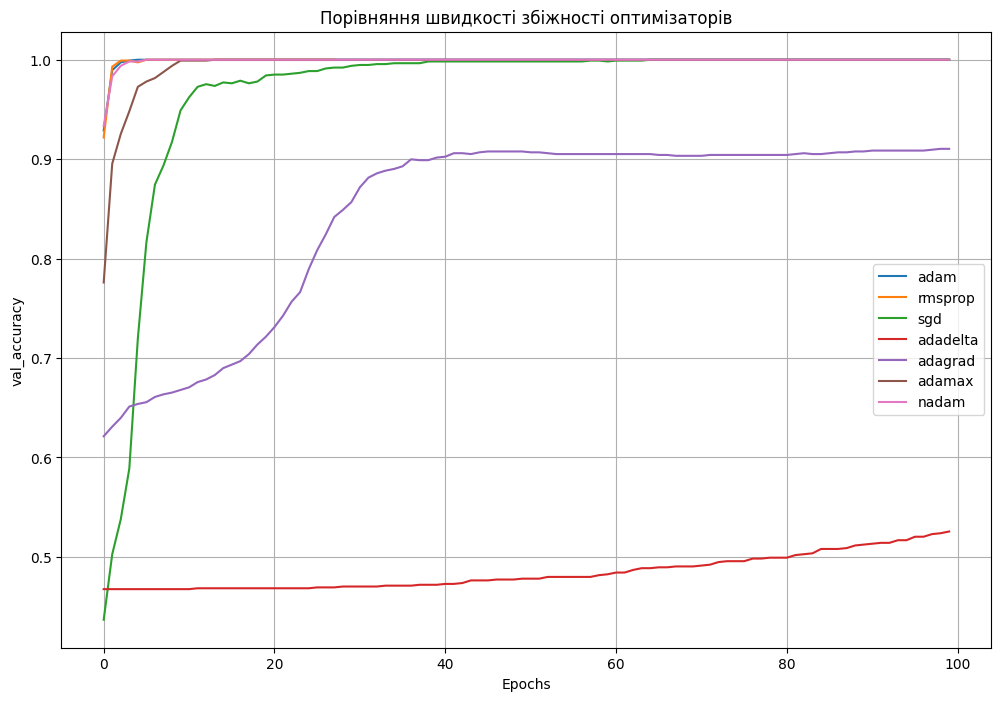

In [20]:
plt.figure(figsize=(12, 8))

# Store validation loss curves and create final accuracy matrix
val_acc = []
final_loss_matrix = np.zeros((len(optimizers), len(activators)))

for opt_idx, (opt, history) in enumerate(zip(optimizers, histories)):
    plt.plot(history[0]['val_accuracy'], label=opt)

    for act_idx in range(len(activators)):
        loss_curve = history[act_idx]['val_accuracy']
        val_acc.append(loss_curve)
        # Store final accuracy value
        final_loss_matrix[opt_idx, act_idx] = loss_curve[-1]

plt.title('Порівняння швидкості збіжності оптимізаторів')
plt.xlabel('Epochs')
plt.ylabel('val_accuracy')
plt.legend()
plt.grid(True)
plt.show()

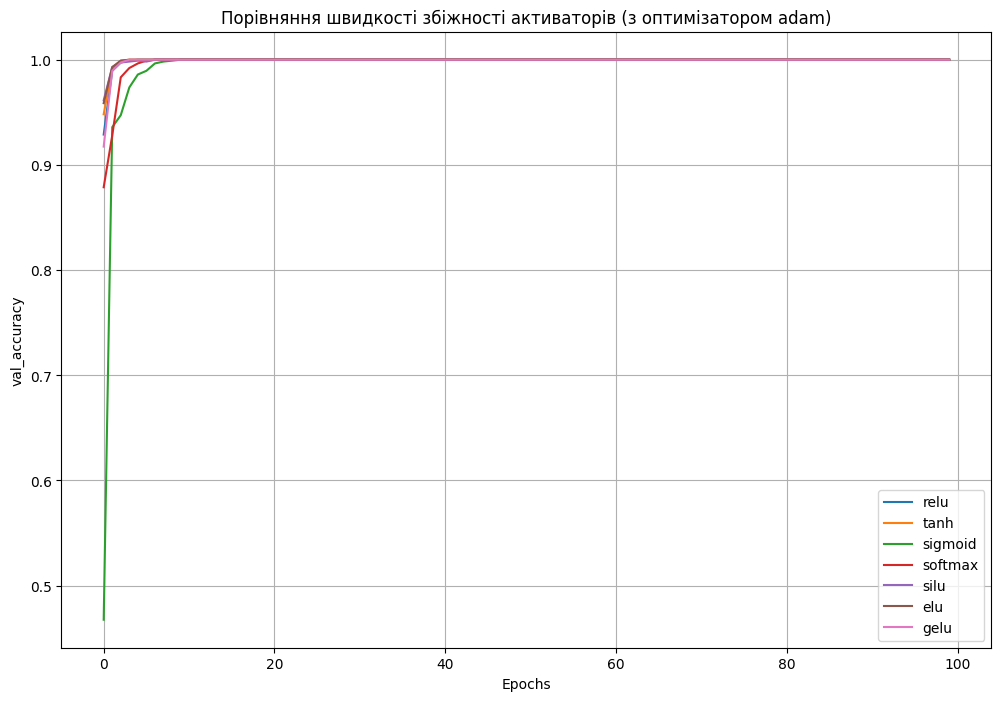

In [22]:
plt.figure(figsize=(12, 8))

# Store validation accuracy curves and create final accuracy matrix
val_acc = []
final_loss_matrix = np.zeros((len(activators), len(optimizers)))

for act_idx, act in enumerate(activators):
    # Для кожного активатора беремо першу модель (з оптимізатором 'adam')
    history_for_act = histories[0][act_idx]  # histories[0] - це для 'adam' оптимізатора
    plt.plot(history_for_act['val_accuracy'], label=act)

    for opt_idx in range(len(optimizers)):
        loss_curve = histories[opt_idx][act_idx]['val_accuracy']
        val_acc.append(loss_curve)
        # Store final loss value
        final_loss_matrix[act_idx, opt_idx] = loss_curve[-1]

plt.title('Порівняння швидкості збіжності активаторів (з оптимізатором adam)')
plt.xlabel('Epochs')
plt.ylabel('val_accuracy')
plt.legend()
plt.grid(True)
plt.show()

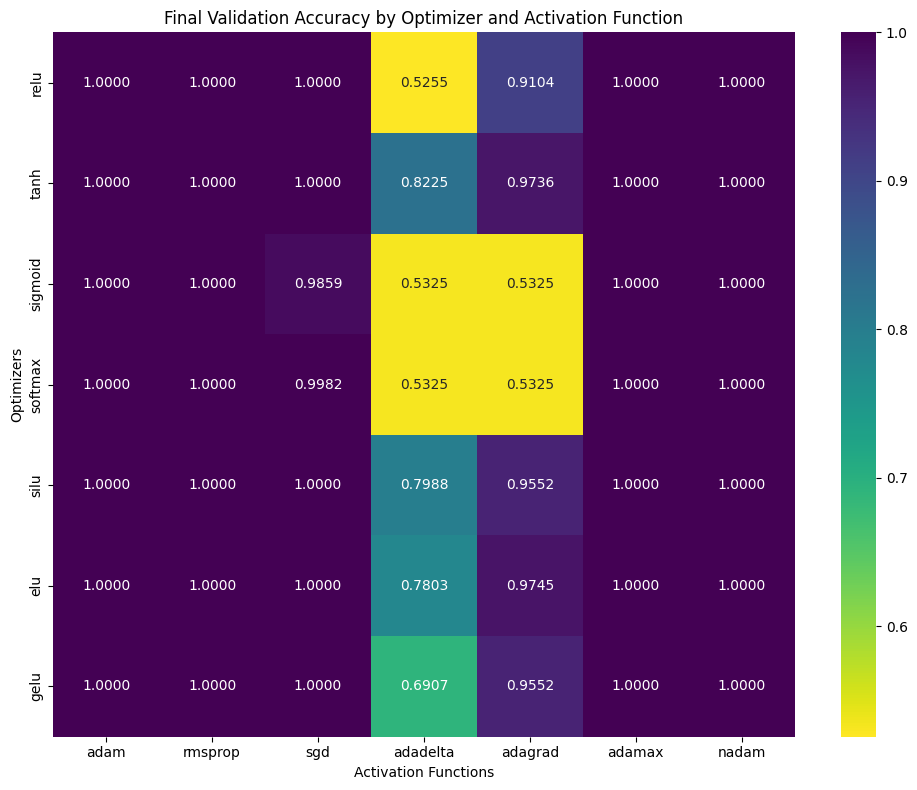

In [23]:
# Plot heatmap of final loss values
plt.figure(figsize=(10, 8))
sns.heatmap(final_loss_matrix,
            xticklabels=optimizers,
            yticklabels=activators,
            annot=True,
            fmt='.4f',
            cmap='viridis_r')
plt.title('Final Validation Accuracy by Optimizer and Activation Function')
plt.xlabel('Activation Functions')
plt.ylabel('Optimizers')
plt.tight_layout()
plt.show()

In [24]:
best_act_idx, best_opt_idx = np.unravel_index(np.argmin(final_loss_matrix), final_loss_matrix.shape)
print(f"Best combination: Activator = {activators[best_act_idx]}, Optimizer = {optimizers[best_opt_idx]}")
print(f"Most final val_accuracy: {final_loss_matrix[best_act_idx, best_opt_idx]:.4f}")

print("\nSorted combinations by val_accuracy:")
combinations = []
for act_idx, act in enumerate(activators):
    for opt_idx, opt in enumerate(optimizers):
        combinations.append((act, opt, final_loss_matrix[act_idx, opt_idx]))

combinations.sort(key=lambda x: x[2], reverse=True)
for act, opt, loss in combinations[:10]:
    print(f"{act:8} + {opt:10}: {loss:.4f}")

Best combination: Activator = relu, Optimizer = adadelta
Most final val_accuracy: 0.5255

Sorted combinations by val_accuracy:
relu     + adam      : 1.0000
relu     + rmsprop   : 1.0000
relu     + sgd       : 1.0000
relu     + adamax    : 1.0000
relu     + nadam     : 1.0000
tanh     + adam      : 1.0000
tanh     + rmsprop   : 1.0000
tanh     + sgd       : 1.0000
tanh     + adamax    : 1.0000
tanh     + nadam     : 1.0000


Check for overfitting

In [10]:
model_new = build_model(X_train, optimizer='adam', activator='relu', layers=2, neurons=10)
early_stopping_monitor = EarlyStopping(patience=3)
model_new.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stopping_monitor],
    verbose=0
)

y_predictions_test = model_new.predict(X_test)
y_predictions_train = model_new.predict(X_train)
test_metrics = get_metrics(y_test, y_predictions_test)
train_metrics = get_metrics(y_train, y_predictions_train)

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [11]:
print('train')
print('Accuracy\tPrecision\t\tRecall\t\tF1')
print('%.3f' % train_metrics[0], '\t\t%.3f\t' % train_metrics[1], '\t%.3f\t' % train_metrics[2],
      '\t%.3f\t' % train_metrics[3])

print('test')
print('Accuracy\tPrecision\t\tRecall\t\tF1')
print('%.3f' % test_metrics[0], '\t\t%.3f\t' % test_metrics[1], '\t%.3f\t' % test_metrics[2],
      '\t%.3f\t' % test_metrics[3])

train
Precision	Recall		Accuracy		R2
1.000 		1.000	 	1.000	 	1.000	
test
Precision	Recall		Accuracy		R2
1.000 		1.000	 	1.000	 	1.000	


Feature: 0, Score: 0.00000
Feature: 1, Score: 0.00000
Feature: 2, Score: 0.00000
Feature: 3, Score: 0.00000
Feature: 4, Score: 0.00000
Feature: 5, Score: 0.00000
Feature: 6, Score: 0.00000
Feature: 7, Score: 0.00211
Feature: 8, Score: 0.00000
Feature: 9, Score: 0.00000
Feature: 10, Score: 0.00000
Feature: 11, Score: 0.00000
Feature: 12, Score: 0.00000
Feature: 13, Score: 0.00000
Feature: 14, Score: 0.00000
Feature: 15, Score: 0.00000
Feature: 16, Score: 0.00000
Feature: 17, Score: 0.00000
Feature: 18, Score: 0.00000
Feature: 19, Score: 0.00000
Feature: 20, Score: 0.00000
Feature: 21, Score: 0.00070
Feature: 22, Score: 0.02307
Feature: 23, Score: 0.00000
Feature: 24, Score: 0.00000
Feature: 25, Score: 0.02296
Feature: 26, Score: 0.00000
Feature: 27, Score: 0.62029
Feature: 28, Score: 0.00000
Feature: 29, Score: 0.00000
Feature: 30, Score: 0.00000
Feature: 31, Score: 0.00000
Feature: 32, Score: 0.00000
Feature: 33, Score: 0.00000
Feature: 34, Score: 0.00000
Feature: 35, Score: 0.00000
Fe

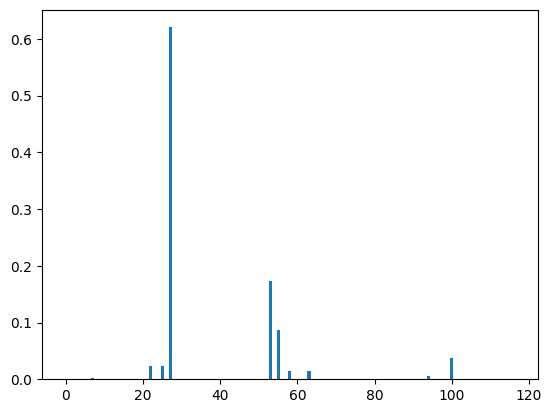

In [34]:
from sklearn.tree import DecisionTreeClassifier
from matplotlib import pyplot as plt

# Define dataset
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

# Get importance
importance = tree.feature_importances_

# Summarize feature importance
for i, v in enumerate(importance):
    print(f'Feature: {i}, Score: {v:.5f}')
plt.bar([x for x in range(len(importance))], importance)
plt.show()